# Forward-Modeling Simulation Populations

Every notebook before this one starts from **parameters** — a double-power-law
SFH with a slope and a timescale, a single metallicity, a dust optical depth —
and asks what SED they imply. A simulation does not hand you parameters. It
hands you **tables**: for each galaxy, the star formation rate at a list of
cosmic times, and the metallicity of the gas those stars formed out of.

```text
    galaxy 0:  t = [0.05, 0.18, 0.31, ...] Gyr
               SFR(t) = [0.0, 0.4, 1.9, ...] Msun/yr
               Z(t)   = [1e-4, 3e-4, 9e-4, ...]      <- metal mass fraction
```

There is no "tau" to fit. The table *is* the history. This notebook takes a
population of such histories and predicts what **SDSS** and **Rubin LSST**
would measure for every galaxy in it — and then measures how fast that goes.

Three things are worth having straight before we start, because each one has
shipped a real bug:

1. **Two metallicities, not one.** The *stellar* metallicity history `met=`
   picks which SSP templates each generation of stars is drawn from. The
   *gas-phase* metallicity `met_gas=` sets the nebular emission. Inflow of
   pristine gas genuinely decouples them, so tengri keeps them as separate
   knobs — and we will measure that they really are separate.
2. **Metallicity has three units in circulation.** A snapshot usually stores
   the raw metal mass fraction *Z*; tengri's user-facing convention is
   log10(Z/Zsun); the SSP grid's own is absolute log10(Z). `Z = 2e-4` is a
   legal value in *two* of those, so a mass fraction read as log10(Z/Zsun) is
   a silent factor of ~70 in metallicity. You declare the unit; nothing guesses.
3. **Simulations run off the edge of the SSP grid.** Early times reach
   near-primordial metallicity, below anything a stellar library tabulates.
   The lookup clips, silently, producing a smooth and wrong SED. tengri
   refuses by default instead.

**What you need:** the bare-stellar SSP grid (fetched automatically below).
Everything else is in the package.

In [1]:
from _setup import FIG_DIR, quiet

quiet()

import time

import matplotlib.pyplot as plt
import numpy as np

import jax

import tengri
from tengri import (
    FIXED,
    Catalog,
    Fixed,
    ForwardModel,
    Observation,
    Photometry,
    SEDModel,
    WavePrecomp,
    plot,
)
from tengri.utils.cosmology import age_at_z

plot.setup_style()

print(
    f"JAX backend: {jax.devices()[0].platform}   "
    f"devices: {jax.device_count()}   x64: {jax.config.jax_enable_x64}"
)

JAX backend: cpu   devices: 1   x64: True


## The bands: SDSS *ugriz* and Rubin LSST *ugrizy*

We predict both surveys at once, for two reasons.

The first is practical: a simulation forward-modeled to SDSS can be compared
against two decades of existing catalogs, and the *same* histories forward-
modeled to LSST tell you what Rubin will see. Same galaxies, both answers,
one pass.

The second is a caution. SDSS *r* and LSST *r* are **not the same filter**.
They share a letter and roughly a bandpass, and they differ enough that
treating one as the other is a systematic. We will measure the size of that
difference on our own population later — it is not a constant, it depends on
the galaxy's spectrum.

`Photometry.from_names` resolves short aliases; `tengri.list_filters()` shows
everything installed.

11 bands: sdss_u, sdss_g, sdss_r, sdss_i, sdss_z, lsst_u, lsst_g, lsst_r, lsst_i, lsst_z, lsst_y


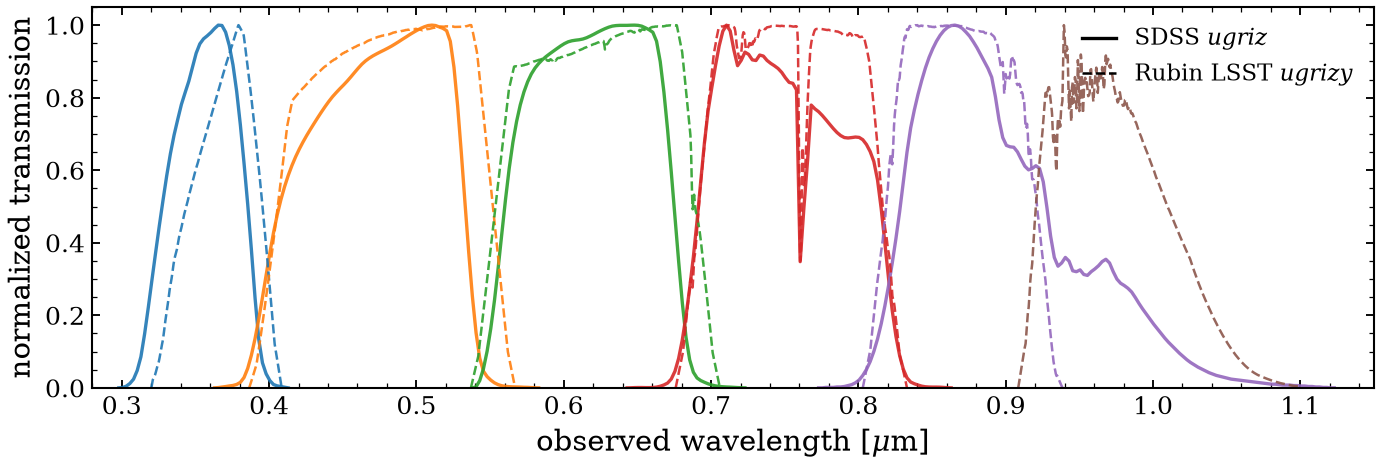

In [2]:
SDSS = [f"sdss_{b}" for b in "ugriz"]
LSST = [f"lsst_{b}" for b in "ugrizy"]
BANDS = SDSS + LSST

phot = Photometry.from_names(BANDS)
print(f"{phot.n_filters} bands: {', '.join(phot.names)}")

fig, ax = plt.subplots(figsize=(9.5, 3.4))
for i, name in enumerate(phot.names):
    w, t = phot.filter_waves[i] / 1e4, phot.filter_trans[i]
    survey_is_sdss = name.startswith("sdss")
    ax.plot(
        w,
        t / t.max(),
        lw=1.6 if survey_is_sdss else 1.2,
        ls="-" if survey_is_sdss else "--",
        color=f"C{'ugrizy'.index(name[-1])}",
        alpha=0.9,
    )
ax.plot([], [], "k-", lw=1.6, label="SDSS $ugriz$")
ax.plot([], [], "k--", lw=1.2, label="Rubin LSST $ugrizy$")
ax.set(
    xlabel=r"observed wavelength [$\mu$m]",
    ylabel="normalized transmission",
    xlim=(0.28, 1.15),
    ylim=(0, 1.05),
)
ax.legend(frameon=False, loc="upper right")
fig.tight_layout()
fig.savefig(FIG_DIR / "12_filters.png", dpi=140)
plt.show()

## A stand-in for a simulation snapshot

A real workflow reads `t`, `SFR(t)` and `Z(t)` out of a hydro snapshot, a
semi-analytic model, or a UniverseMachine-style run. So that this notebook
runs anywhere with no download, we *build* a population with the same shape —
arrays, not parameters — and from here on treat it as opaque tabular data.

**The star formation histories.** A quenched fraction that rises with mass
(downsizing): massive galaxies start early, form fast and shut down; low-mass
galaxies start late and are still forming at the epoch we observe. Each is a
delayed-tau shape, but that is an implementation detail of the *mock* — the
model we fit it through never learns there was a tau.

**The metallicity histories.** The classic closed-box ("simple") chemical
evolution model: with a fixed nucleosynthetic yield *y* and a gas fraction
mu(t) = 1 - M*(<t)/M_baryon,

$$ Z(t) \;=\; y \,\ln\!\frac{1}{\mu(t)} $$

Galaxies that convert a larger share of their gas into stars end up more
metal-rich, so a **mass–metallicity relation falls out** rather than being
imposed. We let the conversion efficiency rise with mass and let the rest
follow. (tengri also ships this as a *parametric* mode you can fit —
`met={'type': 'massmap_box'}`, the ProSpect Lynden-Bell form of
Bellstedt et al. 2020 — for when the enrichment is a thing you want to
infer rather than read off a snapshot.)

The output is in **metal mass fraction**, which is what a snapshot stores,
and which is the unit most likely to be misread.

In [3]:
Z_OBS = 0.1  # the snapshot's redshift
T_OBS = float(age_at_z(Z_OBS))  # age of the universe there [Gyr]
N_T = 96  # nodes per history
YIELD = 0.02  # closed-box nucleosynthetic yield

print(f"snapshot at z = {Z_OBS}: the universe is {T_OBS:.2f} Gyr old")


def simulation_snapshot(n_galaxies, seed=11):
    """Tabulated SFH and Z(t) for a mock population — our stand-in snapshot.

    Returns plain arrays, the way a snapshot reader would: a shared time grid
    [Gyr], per-galaxy SFR [Msun/yr] and metal mass fraction Z, both on that
    grid, plus the bookkeeping we keep only to color the figures.
    """
    rng = np.random.default_rng(seed)
    log_mass = rng.uniform(8.5, 11.5, n_galaxies)

    # Downsizing: the quenched fraction rises through log M* ~ 10.4.
    quenched = rng.random(n_galaxies) < 1.0 / (1.0 + np.exp(-(log_mass - 10.4) / 0.35))
    t_form = np.where(
        quenched, rng.uniform(0.3, 1.5, n_galaxies), rng.uniform(1.0, 4.0, n_galaxies)
    )
    tau = np.where(
        quenched,
        10 ** rng.uniform(-0.30, 0.15, n_galaxies),  # 0.5-1.4 Gyr
        10 ** rng.uniform(0.45, 0.95, n_galaxies),  # 2.8-8.9 Gyr
    )

    t_gyr = np.linspace(0.05, T_OBS, N_T)
    since = np.clip(t_gyr[None, :] - t_form[:, None], 0.0, None)
    sfr = (since / tau[:, None]) * np.exp(-since / tau[:, None])

    # Normalize each history to its target stellar mass formed.
    dt_yr = np.gradient(t_gyr) * 1e9
    sfr *= (10**log_mass / (sfr * dt_yr[None, :]).sum(axis=1))[:, None]

    # Closed box: gas fraction falls as stars form; Z follows.
    mass_formed = np.cumsum(sfr * dt_yr[None, :], axis=1)
    efficiency = np.interp(log_mass, [8.5, 11.5], [0.15, 0.75])
    gas_fraction = 1.0 - mass_formed / (10**log_mass / efficiency)[:, None]
    met = YIELD * np.log(1.0 / gas_fraction)

    return dict(t_gyr=t_gyr, sfr=sfr, met=met, log_mass=log_mass, quenched=quenched)


snap = simulation_snapshot(500)
n_gal = len(snap["log_mass"])
print(f"SFR  array: {snap['sfr'].shape}   [Msun/yr]")
print(
    f"Z(t) array: {snap['met'].shape}   metal mass fraction, "
    f"{snap['met'].min():.2e} .. {snap['met'].max():.2e}"
)
print(f"quenched: {snap['quenched'].sum()} of {len(snap['log_mass'])}")

snapshot at z = 0.1: the universe is 12.47 Gyr old
SFR  array: (500, 96)   [Msun/yr]
Z(t) array: (500, 96)   metal mass fraction, 0.00e+00 .. 2.77e-02
quenched: 178 of 500


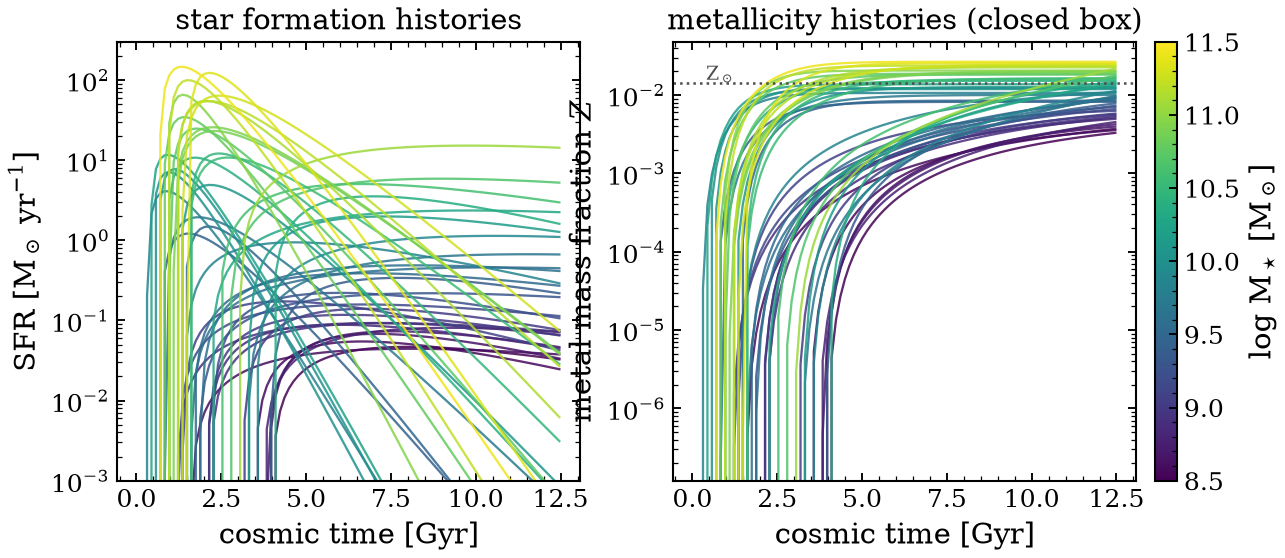

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8))
order = np.argsort(snap["log_mass"])
cmap = plt.get_cmap("viridis")
norm = plt.Normalize(8.5, 11.5)

for i in order[::10]:
    c = cmap(norm(snap["log_mass"][i]))
    axes[0].plot(snap["t_gyr"], snap["sfr"][i], color=c, lw=1.1, alpha=0.85)
    axes[1].plot(snap["t_gyr"], snap["met"][i], color=c, lw=1.1, alpha=0.85)

axes[0].set(
    xlabel="cosmic time [Gyr]",
    ylabel=r"SFR [M$_\odot$ yr$^{-1}$]",
    yscale="log",
    ylim=(1e-3, 3e2),
    title="star formation histories",
)
axes[1].set(
    xlabel="cosmic time [Gyr]",
    ylabel="metal mass fraction $Z$",
    yscale="log",
    title="metallicity histories (closed box)",
)
axes[1].axhline(0.0142, color="0.3", ls=":", lw=1.2)
axes[1].text(0.4, 0.0155, r"Z$_\odot$", color="0.3", fontsize=9)
fig.colorbar(
    plt.cm.ScalarMappable(norm=norm, cmap=cmap),
    ax=axes,
    label=r"log M$_\star$ [M$_\odot$]",
    pad=0.015,
)
fig.savefig(FIG_DIR / "12_histories.png", dpi=140, bbox_inches="tight")
plt.show()

Note the left edge of the right-hand panel: at early times the gas is barely
enriched and *Z* drops below 1e-6. That is physically right and numerically a
problem, and we deal with it in a moment.

## The model: a forward model with **no free parameters**

`sfh={'type': 'table'}` and `met={'type': 'table'}` declare that the SFH and
the metallicity arrive **at runtime, as data**. Neither contributes a fittable
parameter, because there is nothing to fit — the table is the answer. Check
`spec.free_params` below: it is empty. This model is a pure forward operator,
histories in, photometry out.

The nebular backend is a real photoionization grid (`cloudy`) rather than
emission baked into the SSP, because we want the **gas-phase** metallicity to
be a live input. A baked-in grid fixes the nebular conditions at grid-build
time and refuses `met_gas=` — correctly, since nothing would consume it.

`approx=WavePrecomp()` builds the SSP x filter lookup table once and routes
`predict_photometry` through it. It is the speed knob, and we measure what it
buys at the end.

In [5]:
from tengri.parameters.translate import LOG10_ZSUN

ssp = tengri.load_ssp(download=True)  # bare-stellar grid; Cloudy adds the nebular part
ssp_logzsol = np.asarray(ssp.ssp_lgmet) - LOG10_ZSUN
print(f"SSP: {ssp.source}")
print(
    f"  metallicity grid: {len(ssp_logzsol)} nodes, "
    f"log10(Z/Zsun) from {ssp_logzsol.min():.2f} to {ssp_logzsol.max():.2f}"
)


WAVE_PRECOMP = WavePrecomp()  # the SSP x filter lookup table; see the speed section


def build_model(approx=WAVE_PRECOMP):
    """The tabulated-history forward model. One call, so the speed section can vary it."""
    sed = SEDModel.build(
        ssp_data=ssp,
        observation=Observation(photometry=phot),
        redshift=Fixed(Z_OBS),
        sfh={"type": "table"},  # SFH arrives at runtime
        met={"type": "table"},  # so does the stellar metallicity
        dust={"type": "two_component", "law_bc": "calzetti", "*": FIXED},
        neb={"type": "cloudy"},  # live gas-phase metallicity
        approx=approx,
    )
    return ForwardModel.build(sed=sed)


fwd = build_model()
print(f"\nfree parameters: {fwd.spec.free_params}  <- the tables are the model")

SSP: fsps_prsc_miles_chabrier
  metallicity grid: 15 nodes, log10(Z/Zsun) from -2.15 to 0.63


/Users/suchethacooray/Projects/tengri/.claude/worktrees/met-histories/src/tengri/forward/sed_model.py:2503: CloudyGridIonizingSpectrumWarning: CloudyGridBackend: Q_H is computed from your DSPS SSPs (correct for stellar mass accounting), but the ionizing spectral shape used to compute the CLOUDY grid was BPASS v2.1 binary stars. If your SSPs have a significantly harder/softer ionizing SED than BPASS (e.g., single-star models, stripped-star prescriptions, very young/old populations), predicted line ratios will be biased. Use CueBackend if ionizing SED shape variation matters for your science. To suppress: pass ionizing_source_warning='suppress'.
  self._nebular_backend = CloudyGridBackend(spec.cloudy_grid_path, ssp_data)



free parameters: []  <- the tables are the model


The build emits a `CloudyGridIonizingSpectrumWarning`, and it is left visible
on purpose. The Cloudy grid was computed behind a BPASS binary-star ionizing
spectrum, while the ionizing photon rate here comes from our own SSPs. For
broadband colors that mismatch is negligible; for line *ratios* it is a real
systematic, and `neb={'type': 'cue'}` is the backend that lets the ionizing
spectral shape vary. Warnings that describe a live approximation belong on
screen, not in a filter list.

## Ingest: the guard that stops a silent factor of 70

`Catalog.from_histories` is where the tables meet the model, and it validates
**eagerly** — before any compile, before any forward pass. That placement is
deliberate: the metallicity lookup clips onto the SSP grid *inside* JIT, where
no Python exception can be raised. Ingest is the last place a bad history can
still be refused.

Our closed-box histories start from unenriched gas, so *Z* is exactly zero at
the first node and stays far below the grid floor for a while afterwards. That
trips **two** different refusals in sequence, and both are worth seeing.

In [6]:
def try_ingest(met, note):
    """Attempt an ingest and report what came back."""
    print(f"--- {note}")
    try:
        Catalog.from_histories(
            fwd, t_gyr=snap["t_gyr"], sfr=snap["sfr"], met=met, met_unit="z_mass_fraction"
        )
        print("    accepted\n")
        return True
    except ValueError as exc:
        print(f"    REFUSED: {exc}\n")
        return False


try_ingest(snap["met"], "the raw history, straight from the 'snapshot'")

--- the raw history, straight from the 'snapshot'


    REFUSED: met_unit='z_mass_fraction' but 7469 of 48000 values are <= 0 (minimum 0); log10 is undefined there. Primordial gas genuinely has Z = 0 in most simulations, so this is a modeling decision, not a data error: choose a metallicity floor and apply it yourself, e.g. met=np.maximum(Z, 1e-6). Picking one for you would put stars at a metallicity you never chose.



False

The first refusal is arithmetic: log10 is undefined at *Z* = 0. Note what the
message does **not** do — it does not pick a floor for you, because that would
put stars at a metallicity you never chose. So we pick one, deliberately, and
try again with a floor well below the SSP grid.

In [7]:
try_ingest(np.maximum(snap["met"], 1e-8), "floored at Z = 1e-8, below the SSP grid")

--- floored at Z = 1e-8, below the SSP grid


    REFUSED: 9151 of 48000 Z(t) nodes fall outside the SSP metallicity grid [-2.152, 0.626] log10(Z/Zsun) (absolute grid log10(Z) in [-4.000, -1.222]). Those nodes carry 0.2% of the stellar mass formed; the worst is galaxy 0, node 0, at logzsol=-6.152. The metallicity lookup clips to the grid edge, so these would produce a smooth, plausible and wrong SED with no other sign (#442, #1677). Clip the history yourself (np.clip), load an SSP whose grid covers it, or pass on_out_of_grid='warn' to accept the clamp. Check met_unit= first: a metal mass fraction read as log10(Z/Zsun) lands out of grid exactly like this.



False

The second refusal is the interesting one. Those nodes are now perfectly
well-defined numbers — they are simply *off the end of the stellar library*,
where the lookup would clip to the edge and hand back a smooth, plausible,
wrong SED with nothing to indicate it. The message reports the share of
**stellar mass** sitting on clipped nodes, not just a node count, because the
mass share is what decides whether you care.

Three honest responses, and the API makes you pick one:

| response | how | when |
|---|---|---|
| clip the history yourself | `np.maximum(Z, floor)` | the affected mass is negligible |
| load a wider SSP grid | a library reaching lower Z | the affected mass is not negligible |
| accept the clipping | `on_out_of_grid='warn'` / `'ignore'` | you have decided, on the record |

We take the first: a **pre-enrichment floor at the grid's own edge**. Real
galaxies are not primordial by the time they form stars, so this is a modeling
statement rather than a fudge — and now it is one a reader can see.

In [8]:
Z_FLOOR = 10 ** np.asarray(ssp.ssp_lgmet).min()  # the grid's own lowest node
met_floored = np.maximum(snap["met"], Z_FLOOR)
frac_nodes = (snap["met"] < Z_FLOOR).mean()

# The share of stellar MASS on raised nodes — the number that actually matters.
dt_yr = np.gradient(snap["t_gyr"]) * 1e9
mass_per_node = snap["sfr"] * dt_yr[None, :]
frac_mass = mass_per_node[snap["met"] < Z_FLOOR].sum() / mass_per_node.sum()

print(f"floor at Z = {Z_FLOOR:.1e} (the SSP grid's lowest node)")
print(f"  {frac_nodes:.1%} of nodes raised, carrying {frac_mass:.2%} of the stellar mass")
try_ingest(met_floored, "floored at the grid edge")

floor at Z = 1.0e-04 (the SSP grid's lowest node)
  19.1% of nodes raised, carrying 0.24% of the stellar mass
--- floored at the grid edge


    accepted



/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_97265/227959263.py:5: GasStellarMetallicityWarning: the stellar metallicity history reaches -0.64 to 0.29 log10(Z/Zsun) at the present day, but the gas-phase metallicity is fixed at its default -0.30 — up to 0.59 dex apart. They are separate parameters and the gas does not follow the stars, so nebular emission here is computed for gas that never enriched with the population that ionizes it. Pass met_gas= (the same units as met=) to tie them together, or set neb={'logZ_gas': ...} deliberately to keep them apart (#1677).
  Catalog.from_histories(


True

Accepted — but with a `GasStellarMetallicityWarning`, because that trial call
passed a stellar history and said nothing about the gas. The warning is the
subject of the next section, and it is worth reading now: the gas-phase
metallicity did **not** follow the stellar history, it stayed at its declared
default, and the two ended up 0.59 dex apart. The real catalog below sets both.

### Two metallicities, entering by two different doors

`met=` is the **stellar** history: a value per time node, selecting the SSP
templates each generation of stars is drawn from.

`met_gas=` is the **gas-phase** metallicity: one value per galaxy, driving the
nebular emission. Nebular lines come from stars younger than ~10 Myr, so only
the present-day value is observable — we pass the last node of the history.

They are set independently on purpose. If you supply a stellar history and
leave the gas alone, tengri warns rather than quietly enriching the stars and
not the gas: the declared default is a *fixed* 0.5 Zsun that does not follow
your history.

Dust rides along as a third channel — `params=` takes per-galaxy scalars for
anything the histories do not supply. Here we tie the diffuse optical depth to
how actively each galaxy is still forming stars.

In [9]:
# Dust tracks how actively a galaxy is still forming stars: quenched systems have
# cleared their ISM, star-forming ones have not. Kept deliberately gentle — pile
# on too much and dust reddening swamps the color bimodality we want to see.
rng_dust = np.random.default_rng(4)
log_ssfr_now = np.log10(snap["sfr"][:, -1] / 10 ** snap["log_mass"] + 1e-16)
tau_diff = np.clip(
    np.interp(log_ssfr_now, [-12.5, -9.5], [0.05, 0.45]) * rng_dust.lognormal(0, 0.25, n_gal),
    0.02,
    0.9,
)
print(f"dust tau_diff: {tau_diff.min():.2f} .. {tau_diff.max():.2f}")

catalog = Catalog.from_histories(
    fwd,
    t_gyr=snap["t_gyr"],  # (n_t,)      shared grid, broadcast
    sfr=snap["sfr"],  # (N, n_t)    star formation history
    met=met_floored,  # (N, n_t)    STELLAR metallicity history
    met_gas=met_floored[:, -1],  # (N,)        GAS-PHASE metallicity
    met_unit="z_mass_fraction",  # declared, never guessed
    params={"dust_tau_diff": tau_diff},  # (N,)  per-galaxy scalars
)
print(
    f"catalog ready: {len(snap['log_mass'])} galaxies, "
    f"{phot.n_filters} bands, {fwd.spec.free_params} free parameters"
)

dust tau_diff: 0.02 .. 0.71


catalog ready: 500 galaxies, 11 bands, [] free parameters


## Predicting the population

`simulate()` runs the whole catalog through the forward model as **one
vectorized program** and returns photometry plus any derived properties you
ask for. The galaxy axis is `vmap`ped and the result is `jit`ed, so the
catalog costs one compile no matter how many galaxies are in it.

In [10]:
PROPERTIES = ("stellar_mass", "ssfr", "mass_weighted_metallicity", "dn4000", "r23")

t0 = time.perf_counter()
mock = catalog.simulate(properties=PROPERTIES, chunk_size=125)
t_first = time.perf_counter() - t0

t0 = time.perf_counter()
mock = catalog.simulate(properties=PROPERTIES, chunk_size=125)
t_warm = time.perf_counter() - t0

print(f"first call (includes compile): {t_first:6.2f} s")
print(
    f"second call                  : {t_warm:6.2f} s "
    f"-> {1e3 * t_warm / n_gal:.2f} ms/galaxy, {n_gal / t_warm:.0f} galaxies/s"
)
print(f"\nphotometry: {mock.photometry.shape}  [erg/s/cm2/Hz]")

ab_mag = -2.5 * np.log10(mock.photometry / 3631e-23)
mags = {name: ab_mag[:, i] for i, name in enumerate(phot.names)}
props = {k: np.asarray(v) for k, v in mock.properties.items()}

first call (includes compile):   6.21 s
second call                  :   2.18 s -> 4.35 ms/galaxy, 230 galaxies/s

photometry: (500, 11)  [erg/s/cm2/Hz]


### Does the forward model reproduce what we put in?

The first thing to check on any mock is that the tables survived the trip.
`stellar_mass` is a derived property integrated from the SFH *inside* the
model; our target masses never entered as a parameter, so this is a real
round-trip and not a tautology.

In [11]:
recovered = np.log10(props["stellar_mass"])
residual = recovered - snap["log_mass"]
print(f"log M* recovered - input:  max |diff| = {np.abs(residual).max():.2e} dex")
print(
    f"mass-weighted stellar log(Z/Zsun): "
    f"{props['mass_weighted_metallicity'].min():.2f} .. "
    f"{props['mass_weighted_metallicity'].max():.2f}"
)

log M* recovered - input:  max |diff| = 4.59e-03 dex
mass-weighted stellar log(Z/Zsun): -1.07 .. -0.19


A few thousandths of a dex, not zero — and that is the expected answer, not a
bug. We normalized the histories with a `np.gradient` trapezoid over 96 nodes;
the model re-integrates the same table onto the SSP age grid with its own
quadrature. Two quadratures of one table differ at the discretization level.
Add nodes and the gap shrinks. What would *not* be expected is a systematic
offset or a mass-dependent trend — those would mean a real disagreement about
what the table says.

### The color–mass diagram

This is the payoff: a red sequence and a blue cloud, produced by nothing but
the tabulated histories going through the forward model. Neither the
bimodality nor the mass–metallicity relation was put in as a color or a
metallicity *parameter* — both are consequences of the SFHs and the closed-box
enrichment.

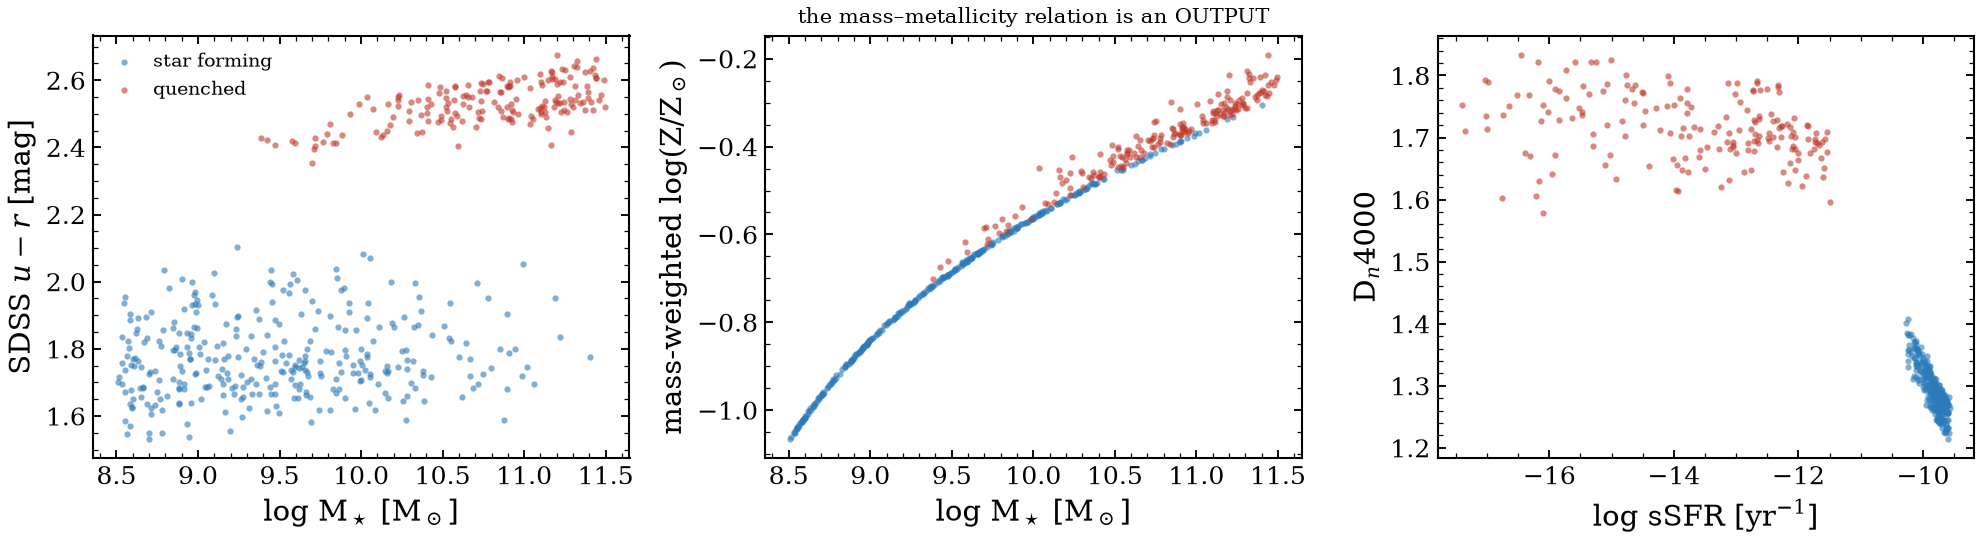

u-r  quenched 2.53 +- 0.06   star forming 1.77 +- 0.12


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.9))
q = snap["quenched"]
u_r = mags["sdss_u"] - mags["sdss_r"]

for ax, (x, y, xl, yl) in zip(
    axes,
    [
        (snap["log_mass"], u_r, r"log M$_\star$ [M$_\odot$]", "SDSS $u - r$ [mag]"),
        (
            snap["log_mass"],
            props["mass_weighted_metallicity"],
            r"log M$_\star$ [M$_\odot$]",
            r"mass-weighted log(Z/Z$_\odot$)",
        ),
        (np.log10(props["ssfr"]), props["dn4000"], r"log sSFR [yr$^{-1}$]", r"D$_n$4000"),
    ],
):
    ax.scatter(x[~q], y[~q], s=9, c="#2b7bba", alpha=0.6, lw=0, label="star forming")
    ax.scatter(x[q], y[q], s=9, c="#c0392b", alpha=0.6, lw=0, label="quenched")
    ax.set(xlabel=xl, ylabel=yl)
axes[0].legend(frameon=False, fontsize=9, loc="upper left")
axes[1].set_title("the mass–metallicity relation is an OUTPUT", fontsize=10)
fig.tight_layout()
fig.savefig(FIG_DIR / "12_color_mass.png", dpi=140)
plt.show()

print(
    f"u-r  quenched {u_r[q].mean():.2f} +- {u_r[q].std():.2f}   "
    f"star forming {u_r[~q].mean():.2f} +- {u_r[~q].std():.2f}"
)

## SDSS is not Rubin

Both surveys observed the same 500 galaxies here, so the difference between
them is purely the filters. Same letter, different throughput — and because
the offset depends on the galaxy's spectrum, it is **not** a constant you can
subtract.

band    <SDSS - LSST>   scatter            range
u             +0.119     0.047  [+0.065, +0.192]
g             +0.056     0.010  [+0.039, +0.075]
r             +0.010     0.001  [+0.007, +0.014]
i             +0.006     0.002  [+0.001, +0.009]
z             -0.036     0.004  [-0.048, -0.024]


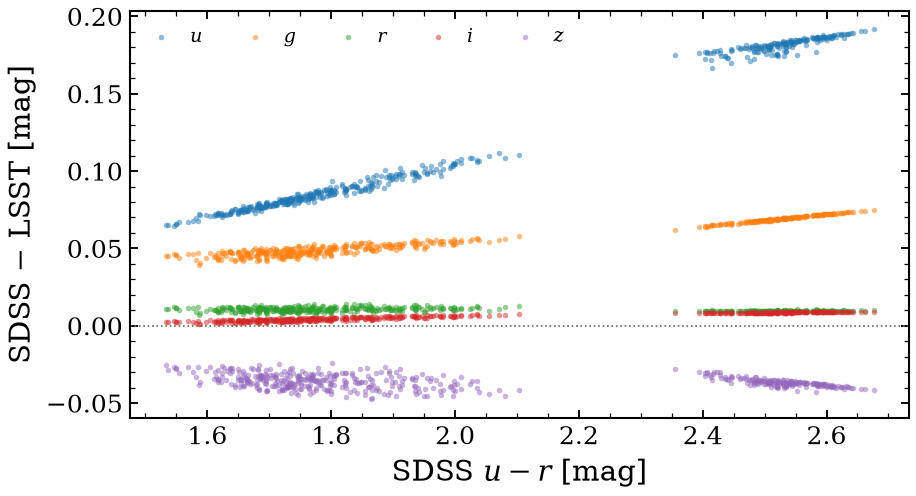

In [13]:
print(f"{'band':6s} {'<SDSS - LSST>':>14s} {'scatter':>9s} {'range':>16s}")
for b in "ugriz":
    d = mags[f"sdss_{b}"] - mags[f"lsst_{b}"]
    print(f"{b:6s} {d.mean():+13.3f}  {d.std():8.3f}  [{d.min():+.3f}, {d.max():+.3f}]")

fig, ax = plt.subplots(figsize=(6.4, 3.6))
for b, c in zip("ugriz", ["C0", "C1", "C2", "C3", "C4"]):
    ax.scatter(
        u_r, mags[f"sdss_{b}"] - mags[f"lsst_{b}"], s=7, alpha=0.5, lw=0, color=c, label=f"${b}$"
    )
ax.axhline(0, color="0.4", lw=0.8, ls=":")
ax.set(xlabel="SDSS $u - r$ [mag]", ylabel="SDSS $-$ LSST [mag]")
ax.legend(frameon=False, ncol=5, fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / "12_sdss_vs_lsst.png", dpi=140)
plt.show()

The *u* band is the worst — the offset there is a tenth of a magnitude and it
**slides with galaxy color**, which is exactly the signature of a systematic
that a single zero-point correction cannot remove.

## The two metallicities really are two knobs

Here is the claim from the introduction, measured. We re-run a small
sub-catalog three times:

1. **baseline** — as built above;
2. **gas knob** — gas-phase metallicity divided by 5, *stellar history
   untouched*;
3. **stellar knob** — stellar history divided by 5, *gas untouched*.

and watch two diagnostics: `mass_weighted_metallicity` (a property of the
stars) and `r23` (a classic **gas-phase** metallicity indicator built from
[OII], [OIII] and Hbeta).

If the knobs are genuinely separate, each should move its own diagnostic and
leave the other alone.

In [14]:
SUB = 24
sfr_sub = snap["sfr"][:SUB]
met_sub = met_floored[:SUB]
gas_sub = met_sub[:, -1]


def probe(met, met_gas):
    """Simulate the sub-catalog under one setting of the two metallicity knobs."""
    cat = Catalog.from_histories(
        fwd,
        t_gyr=snap["t_gyr"],
        sfr=sfr_sub,
        met=met,
        met_gas=met_gas,
        met_unit="z_mass_fraction",
    )
    out = cat.simulate(properties=("mass_weighted_metallicity", "r23"), chunk_size=SUB)
    return {k: np.asarray(v) for k, v in out.properties.items()}


base = probe(met_sub, gas_sub)
gas_knob = probe(met_sub, gas_sub / 5.0)
star_knob = probe(np.maximum(met_sub / 5.0, Z_FLOOR), gas_sub)

print(f"{'diagnostic':30s} {'turn the GAS knob':>19s} {'turn the STELLAR knob':>23s}")
for key in ("mass_weighted_metallicity", "r23"):
    d_gas = np.abs(gas_knob[key] - base[key]).max()
    d_star = np.abs(star_knob[key] - base[key]).max()
    print(f"{key:30s} {d_gas:18.4f}  {d_star:22.4f}")
print("\n(max |change| in dex across the sub-catalog)")

diagnostic                       turn the GAS knob   turn the STELLAR knob
mass_weighted_metallicity                  0.0000                  0.6990
r23                                        1.1308                  0.0176

(max |change| in dex across the sub-catalog)


The stellar knob moves the stellar metallicity and barely touches `r23`; the
gas knob moves `r23` by more than a dex and leaves the stellar metallicity at
**exactly** zero change. That is the separation the API promises, and it is
why a snapshot that stores both should pass both.

## Speed

Everything above ran on one catalog. This section takes the cost apart. All
numbers below are from *this* machine, on the backend printed at the top —
re-run it rather than quoting these.

There are four costs, and they behave completely differently:

| cost | scales with | pay it |
|---|---|---|
| building the model | nothing | once per session |
| `from_histories` validation | nothing | once per catalog |
| the first `predict` (XLA compile) | nothing | once per shape |
| `predict` itself | N | every call |

The first three are **fixed**. That is the whole design: make the per-galaxy
cost the only thing that grows.

In [15]:
small = simulation_snapshot(64, seed=3)
small_met = np.maximum(small["met"], Z_FLOOR)


def make_catalog(model, s, met):
    return Catalog.from_histories(
        model,
        t_gyr=s["t_gyr"],
        sfr=s["sfr"],
        met=met,
        met_gas=met[:, -1],
        met_unit="z_mass_fraction",
    )


t0 = time.perf_counter()
_ = build_model()
t_build = time.perf_counter() - t0

t0 = time.perf_counter()
cat_small = make_catalog(fwd, small, small_met)
t_ingest = time.perf_counter() - t0

t0 = time.perf_counter()
cat_small.predict(chunk_size=64)
t_compile = time.perf_counter() - t0

t0 = time.perf_counter()
cat_small.predict(chunk_size=64)
t_run = time.perf_counter() - t0

print(f"build the model          {t_build:7.2f} s   (once per session)")
print(f"from_histories(N=64)     {t_ingest:7.2f} s   (once per catalog)")
print(f"first predict, compiling {t_compile:7.2f} s   (once per shape)")
print(f"predict, warm            {t_run:7.3f} s   -> {1e3 * t_run / 64:.2f} ms/galaxy")

/Users/suchethacooray/Projects/tengri/.claude/worktrees/met-histories/src/tengri/forward/sed_model.py:2503: CloudyGridIonizingSpectrumWarning: CloudyGridBackend: Q_H is computed from your DSPS SSPs (correct for stellar mass accounting), but the ionizing spectral shape used to compute the CLOUDY grid was BPASS v2.1 binary stars. If your SSPs have a significantly harder/softer ionizing SED than BPASS (e.g., single-star models, stripped-star prescriptions, very young/old populations), predicted line ratios will be biased. Use CueBackend if ionizing SED shape variation matters for your science. To suppress: pass ionizing_source_warning='suppress'.
  self._nebular_backend = CloudyGridBackend(spec.cloudy_grid_path, ssp_data)


build the model             1.42 s   (once per session)
from_histories(N=64)        4.28 s   (once per catalog)
first predict, compiling    0.99 s   (once per shape)
predict, warm              0.271 s   -> 4.24 ms/galaxy


### Where the loop actually loses

The alternative to a catalog is the obvious loop: one galaxy, one prediction,
repeat. It is correct, and it is a trap — but *not* for the reason people
usually give. Let us take the loop apart rather than quote a headline number.

In [16]:
LOOP_N = 16

# (a) the naive loop: a fresh single-galaxy catalog each time
t0 = time.perf_counter()
for i in range(LOOP_N):
    one_galaxy = {"t_gyr": small["t_gyr"], "sfr": small["sfr"][i : i + 1]}
    make_catalog(fwd, one_galaxy, small_met[i : i + 1]).predict(chunk_size=1)
t_loop = time.perf_counter() - t0

# (b) the same loop with the catalog reused — validation paid once, predict N times
solo = make_catalog(fwd, {"t_gyr": small["t_gyr"], "sfr": small["sfr"][:1]}, small_met[:1])
solo.predict(chunk_size=1)  # compile width 1
t0 = time.perf_counter()
for _ in range(LOOP_N):
    solo.predict(chunk_size=1)
t_solo = time.perf_counter() - t0

# (c) one catalog of exactly LOOP_N galaxies, one vectorized call — warmed, so
#     this is steady state and the galaxy count matches (a) and (b) exactly.
cat_loop = make_catalog(
    fwd, {"t_gyr": small["t_gyr"], "sfr": small["sfr"][:LOOP_N]}, small_met[:LOOP_N]
)
cat_loop.predict(chunk_size=LOOP_N)  # compile this width
t0 = time.perf_counter()
cat_loop.predict(chunk_size=LOOP_N)
t_batch = time.perf_counter() - t0

print(f"(a) fresh catalog per galaxy  {1e3 * t_loop / LOOP_N:9.1f} ms/galaxy")
print(f"(b) one catalog, N predicts   {1e3 * t_solo / LOOP_N:9.1f} ms/galaxy")
print(f"(c) one vectorized predict    {1e3 * t_batch / LOOP_N:9.1f} ms/galaxy")
print(f"\n(a) -> (b): {t_loop / t_solo:6.0f}x   stop revalidating")
print(f"(b) -> (c): {t_solo / t_batch:6.1f}x   vectorize the arithmetic")

(a) fresh catalog per galaxy     4466.1 ms/galaxy
(b) one catalog, N predicts         8.5 ms/galaxy
(c) one vectorized predict          4.0 ms/galaxy

(a) -> (b):    523x   stop revalidating
(b) -> (c):    2.2x   vectorize the arithmetic


Two steps, two very different sizes, and the big one is not the one people
expect. Going from (a) to (b) is a factor of *hundreds* and involves no
vectorization at all — it is simply not re-running `from_histories` validation
once per galaxy. Going from (b) to (c), the actual `vmap`, is a modest factor
on CPU, where a handful of cores are already busy.

So the rule is **"build one catalog"**, not "vectorization is magic". The
vectorization matters most on a GPU, where the same program has hundreds of
lanes to fill; the validation cost is pure overhead everywhere.

(`from_histories` is heavier than it needs to be: it rebuilds the model's
component chain three times to ask three *static* configuration questions —
is the SFH tabulated, is there a nebular backend, what is the SSP metallicity
grid. That is tengri issue #1769. The operational advice above holds either
way, and gets cheaper if the issue is fixed.)

### What `WavePrecomp` buys

The exact path integrates the SSP x filter product on the full wavelength
grid. `WavePrecomp` tabulates it once at build time and interpolates. It costs
a slower build and returns it on every evaluation.

In [17]:
bench = simulation_snapshot(256, seed=5)
bench_met = np.maximum(bench["met"], Z_FLOOR)

for label, approx in (("exact grid", None), ("WavePrecomp", WAVE_PRECOMP)):
    t0 = time.perf_counter()
    model = build_model(approx)
    tb = time.perf_counter() - t0
    cat_b = make_catalog(model, bench, bench_met)
    cat_b.predict(chunk_size=128)  # compile
    times = []
    for _ in range(3):
        t0 = time.perf_counter()
        cat_b.predict(chunk_size=128)
        times.append(time.perf_counter() - t0)
    tw = min(times)
    print(
        f"{label:12s} build {tb:5.2f} s   warm {tw:6.3f} s   "
        f"{1e3 * tw / 256:5.2f} ms/galaxy   {256 / tw:6.0f} galaxies/s"
    )

/Users/suchethacooray/Projects/tengri/.claude/worktrees/met-histories/src/tengri/forward/sed_model.py:2503: CloudyGridIonizingSpectrumWarning: CloudyGridBackend: Q_H is computed from your DSPS SSPs (correct for stellar mass accounting), but the ionizing spectral shape used to compute the CLOUDY grid was BPASS v2.1 binary stars. If your SSPs have a significantly harder/softer ionizing SED than BPASS (e.g., single-star models, stripped-star prescriptions, very young/old populations), predicted line ratios will be biased. Use CueBackend if ionizing SED shape variation matters for your science. To suppress: pass ionizing_source_warning='suppress'.
  self._nebular_backend = CloudyGridBackend(spec.cloudy_grid_path, ssp_data)


exact grid   build  0.02 s   warm  1.445 s    5.65 ms/galaxy      177 galaxies/s


/Users/suchethacooray/Projects/tengri/.claude/worktrees/met-histories/src/tengri/forward/sed_model.py:2503: CloudyGridIonizingSpectrumWarning: CloudyGridBackend: Q_H is computed from your DSPS SSPs (correct for stellar mass accounting), but the ionizing spectral shape used to compute the CLOUDY grid was BPASS v2.1 binary stars. If your SSPs have a significantly harder/softer ionizing SED than BPASS (e.g., single-star models, stripped-star prescriptions, very young/old populations), predicted line ratios will be biased. Use CueBackend if ionizing SED shape variation matters for your science. To suppress: pass ionizing_source_warning='suppress'.
  self._nebular_backend = CloudyGridBackend(spec.cloudy_grid_path, ssp_data)


WavePrecomp  build  1.59 s   warm  0.899 s    3.51 ms/galaxy      285 galaxies/s


### `chunk_size`: the memory knob

`chunk_size` sets how many galaxies are `vmap`ped at once. Bigger batches
amortize better — up to a point — and cost memory **linearly**. With
tabulated histories each galaxy carries its own SFH and Z(t) arrays through
the SSP machinery, so the default of 1024 is genuinely large: it was enough to
exhaust memory on the laptop this notebook was written on. If a catalog dies
without a Python traceback, this is the first knob to turn *down*.

In [18]:
cat_bench = make_catalog(fwd, bench, bench_met)
print(f"{'chunk_size':>11s} {'wall':>8s} {'ms/galaxy':>11s} {'galaxies/s':>12s}")
for chunk in (16, 32, 64, 128):
    cat_bench.predict(chunk_size=chunk)  # compile this width
    t0 = time.perf_counter()
    cat_bench.predict(chunk_size=chunk)
    dt = time.perf_counter() - t0
    print(f"{chunk:11d} {dt:7.2f}s {1e3 * dt / 256:10.2f} {256 / dt:11.0f}")

 chunk_size     wall   ms/galaxy   galaxies/s


         16    1.23s       4.79         209


         32    1.21s       4.72         212


         64    1.07s       4.18         239


        128    1.03s       4.02         249


### Scaling

The point of the fixed-cost design: past the compile, per-galaxy cost is
roughly **flat** in *N* — doubling the catalog roughly doubles the wall clock
and does nothing else. Expect some scatter between rows below: these are
single timings on a shared machine, so a ~20% spread is measurement noise
rather than a scaling term. What would matter is a *monotonic* climb with *N*.

In [19]:
print(f"{'N':>7s} {'wall':>9s} {'ms/galaxy':>11s} {'galaxies/s':>12s}")
for n in (128, 512, 2048):
    s = simulation_snapshot(n, seed=17)
    c = make_catalog(fwd, s, np.maximum(s["met"], Z_FLOOR))
    c.predict(chunk_size=128)
    t0 = time.perf_counter()
    c.predict(chunk_size=128)
    dt = time.perf_counter() - t0
    print(f"{n:7d} {dt:8.2f}s {1e3 * dt / n:10.2f} {n / dt:11.0f}")

      N      wall   ms/galaxy   galaxies/s


    128     0.41s       3.21         311


    512     1.66s       3.25         308


   2048     5.78s       2.82         354


On a GPU the same program fills the card's lanes instead of a handful of CPU
cores, and the per-galaxy number drops by a large factor with no code change —
`chunk_size` is then bounded by device memory rather than host RAM.

## What to take away

* A simulation enters tengri as **tables**, through
  `Catalog.from_histories(...)`. `sfh={'type': 'table'}` and
  `met={'type': 'table'}` declare a model with **zero free parameters** — a
  pure forward operator.
* **Declare the metallicity unit.** `met_unit="z_mass_fraction"` is what a
  snapshot stores. Left at the default it would be read as log10(Z/Zsun) — a
  silent factor of ~70, and *in-grid*, so no range check can catch it.
* **Stellar and gas-phase metallicity are separate knobs**, and we measured
  that they are: the gas knob moved `r23` by >1 dex and the stellar
  metallicity by exactly zero.
* **The off-grid guard is on by default** and reports the affected *stellar
  mass*, not just a node count. Clip deliberately, widen the grid, or downgrade
  the policy on the record.
* **Fixed costs stay fixed.** Model build, validation and compile do not scale
  with the catalog; only `predict` does. Build one catalog, not N.

### Where to go next

* [`11_catalog_fits.py`](11_catalog_fits.ipynb) — the inverse problem: fitting a
  catalog of *observed* photometry in parallel.
* [`04_building_models.py`](04_building_models.ipynb) — the full build grammar,
  including the parametric metallicity modes (`ramp`, `massmap_box`,
  `chem_evol`) for when enrichment is something you want to infer.
* `tengri.list_metallicity_modes()` — the live menu of everything `met=`
  accepts.